# Performance Test 

The test will plot the ROC of the algorithms. There are two modes: Full which test both non conjugate and conjugate SCD; limited which test only non conjugate SCD and with limited range.

The algorithm ability to detect cycle frequency under heavy noise will determine its performance. The cycle frequency tested are:

- Full:
    - Rect BPSK: 0.8 Hz Non Conj, -0.8 Hz Conj
    - SRRC QPSK: 0.1 Hz Non Conj, 0.1 Hz Conj
    - GMSK: 0.1 Hz Non Conj, 0.15 Hz Conj

- Limited:
    - Rect BPSK: 0.4 Hz Non Conj
    - SRRC QPSK: 0.1 Hz Non Conj
    - GMSK: 0.1 Hz Non Conj

The signal paramters are 0.1 Hz Symbol Rate, 0.05 Hz CFO, SRRC filter length of 21, SRRC beta of 0.5 and Bandwidth time product of 0.3 for GMSK.

Usage:

```
plot_roc_full(func_lambda, Np=8, no_of_simulation=1000, threshold_resolution=10000, snr=[0], N=2**12, fam=False, L=2, name="roc", save=False)

plot_roc_limited(func_lambda, Np=8, no_of_simulation=1000, threshold_resolution=10000, snr=[0], N=2**12, fam=False, L=2, name="roc", save=False)
```

The higher the snr, the easier the test. Same for N (signal length).

In [1]:
import numpy as np
import scf_test.tests as test
import pandas as pd
from scf_test.algorithm import ssca, fam, Fast_SC, fam_flattop, ssca_flattop, scf_2d_fft, psd

Starting non-conjugate ROC test for fam_roc...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 1.715/3
-5dB SNR Score: 1.660/3
-10dB SNR Score: 1.561/3


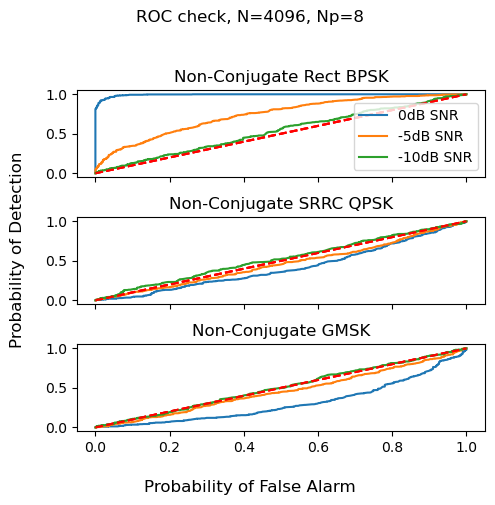

In [3]:
# For cycle frequency far from 0, it is better to set small Np for high time frequency product -> better resistance against noise

fam_pd, fam_pf, fam_roc_auc, threshold_resolution = test.plot_roc_non_conjugate(fam, Np=8, L=2, fam=True, no_of_simulation=500, snr=[0, -5, -10], name="fam_roc") # fam=True for L paramter

Starting non-conjugate ROC test for ssca_roc...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 1.915/3
-5dB SNR Score: 1.706/3
-10dB SNR Score: 1.504/3


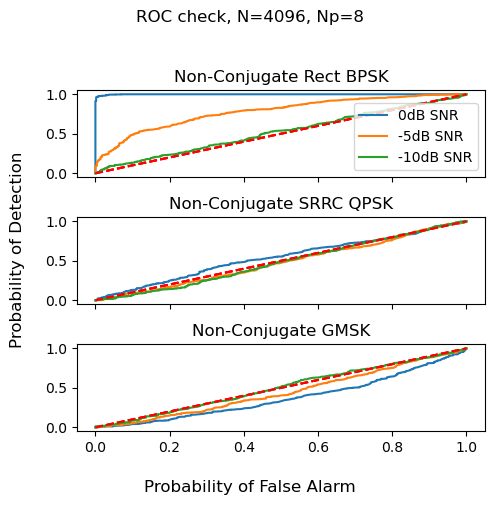

In [4]:
ssca_pd, ssca_pf, ssca_roc_auc, threshold_resolution = test.plot_roc_non_conjugate(ssca, Np=8, no_of_simulation=500, snr=[0, -5, -10], name="ssca_roc") 

For algorithm that only outputs non conjugate SCD and have limited cycle frequency range like FastSC, we have a modified version of the test for them.

Starting non-conjugate ROC test for fastsc_roc...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 1.874/3
-5dB SNR Score: 1.698/3
-10dB SNR Score: 1.526/3


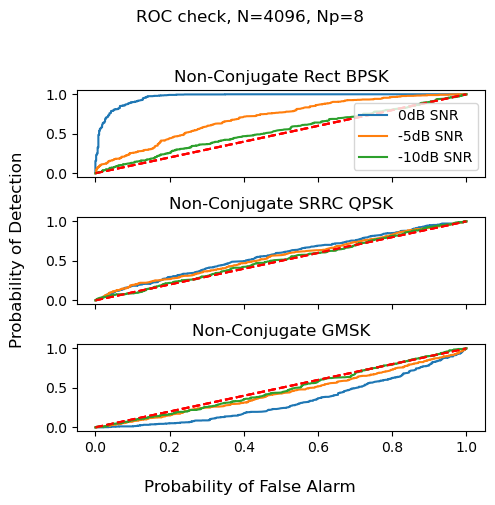

In [5]:
fastsc_pd_limited, fastsc_pf_limited, fastsc_roc_auc_limited, threshold_resolution = test.plot_roc_non_conjugate(fast_sc_wrapper, Np=8, no_of_simulation=500, snr=[0, -5, -10], name="fastsc_roc") 

You can change parameters like N and Np in the function too.

Starting non-conjugate ROC test for fam_roc_long_N...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
-10dB SNR Score: 2.747/3


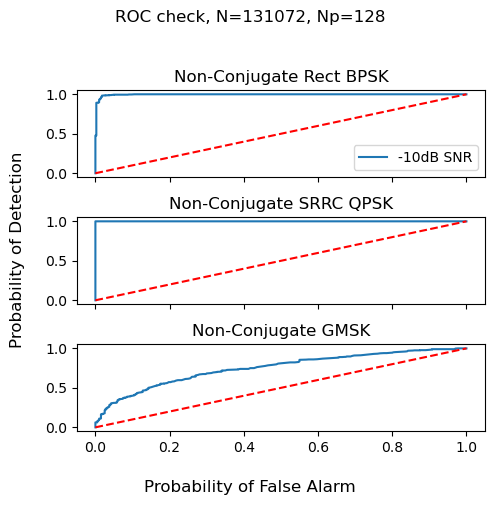

In [7]:
fam_pd, fam_pf, fam_roc_auc, threshold_resolution = test.plot_roc_non_conjugate(fam, Np=128, L=32, fam=True, no_of_simulation=400, N=2**17, snr=[-10], name="fam_roc_long_N") # fam=True for L paramter

In [ ]:
ssca_pd, ssca_pf, ssca_roc_auc, threshold_resolution = test.plot_roc_non_conjugate(ssca, Np=128, no_of_simulation=400, snr=[-10], N=2**17, name="ssca_roc_long_N") 

Starting non-conjugate ROC test for ssca_roc_long_N...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000


In [ ]:
fastsc_pd_limited, fastsc_pf_limited, fastsc_roc_auc_limited, threshold_resolution = test.plot_roc_non_conjugate(fast_sc_wrapper, Np=128, no_of_simulation=400, N=2**17, snr=[-10], name="fastsc_roc_long_N") 

Varying Np

In [2]:
snr = [0, -5, -10]
Np = [8, 16, 32, 64, 128, 256]

len_snr = len(snr)
len_np = len(Np)

fam_auc_nc_score = np.zeros((len_np, len_snr))
fam_auc_c_score = np.zeros((len_np, len_snr))

ssca_auc_nc_score = np.zeros((len_np, len_snr))
ssca_auc_c_score = np.zeros((len_np, len_snr))

fam_flat_auc_nc_score = np.zeros((len_np, len_snr))
fam_flat_auc_c_score = np.zeros((len_np, len_snr))

ssca_flat_auc_nc_score = np.zeros((len_np, len_snr))
ssca_flat_auc_c_score = np.zeros((len_np, len_snr))

fastsc_auc_nc_score = np.zeros((len_np, len_snr))

fastsc_flat_auc_nc_score = np.zeros((len_np, len_snr))

scf_2d_fft_auc_nc_score = np.zeros((len_np, len_snr))
scf_2d_fft_auc_c_score = np.zeros((len_np, len_snr))

scf_2d_fft_flat_auc_nc_score = np.zeros((len_np, len_snr))
scf_2d_fft_flat_auc_c_score = np.zeros((len_np, len_snr))

Starting non-conjugate ROC test for fam_8...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 1.670/3
-5dB SNR Score: 1.624/3
-10dB SNR Score: 1.494/3


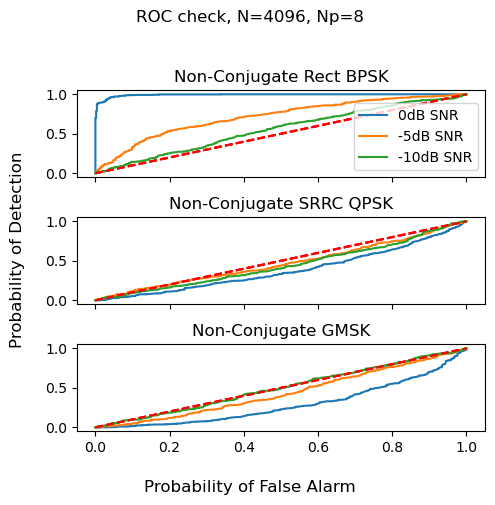

Starting conjugate ROC test for fam_8...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.249/3
-5dB SNR Score: 1.984/3
-10dB SNR Score: 1.660/3


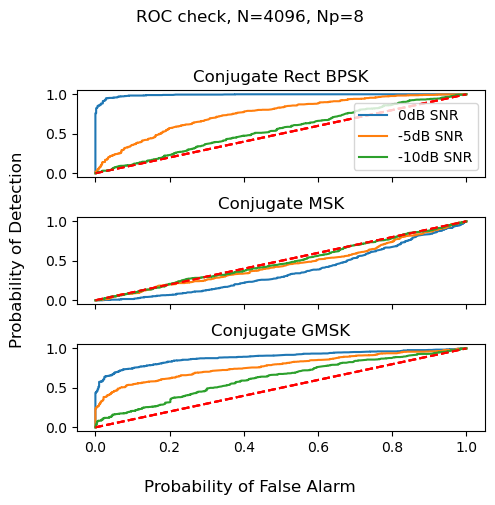

Starting non-conjugate ROC test for ssca_8...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 1.907/3
-5dB SNR Score: 1.725/3
-10dB SNR Score: 1.510/3


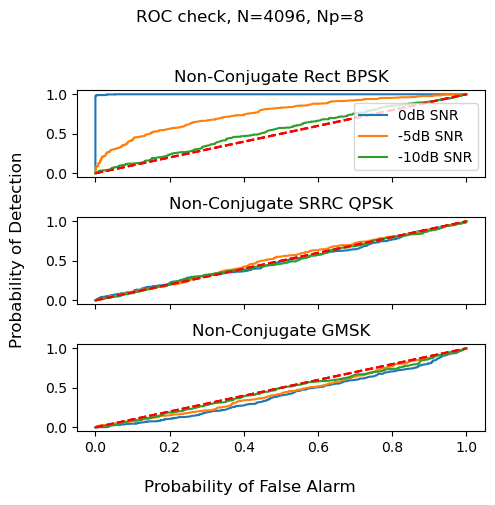

Starting conjugate ROC test for ssca_8...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.302/3
-5dB SNR Score: 2.114/3
-10dB SNR Score: 1.678/3


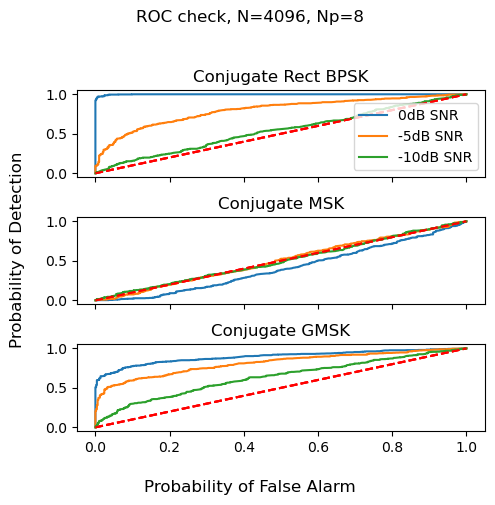

Starting non-conjugate ROC test for fam_flat_8...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.122/3
-5dB SNR Score: 1.705/3
-10dB SNR Score: 1.473/3


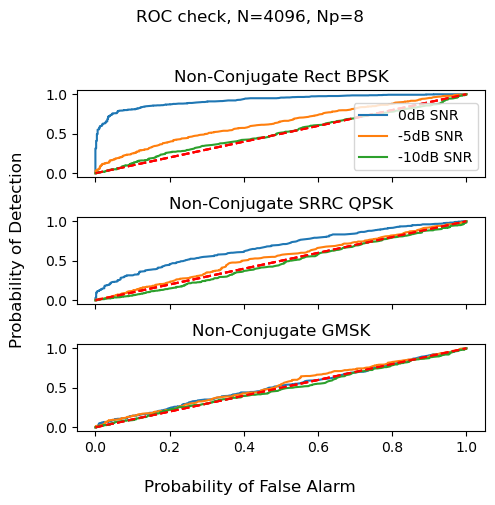

Starting conjugate ROC test for fam_flat_8...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.432/3
-5dB SNR Score: 2.021/3
-10dB SNR Score: 1.645/3


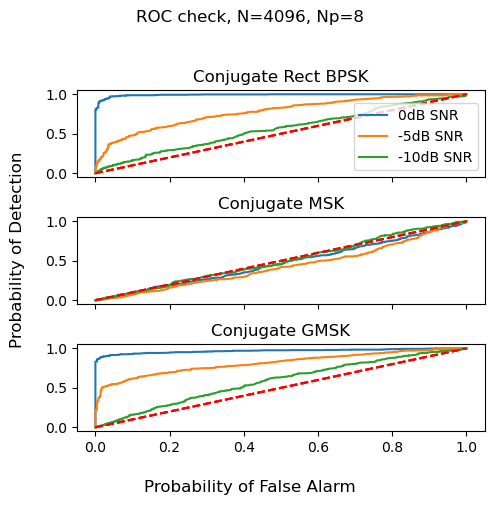

Starting non-conjugate ROC test for ssca_flat_8...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.357/3
-5dB SNR Score: 1.768/3
-10dB SNR Score: 1.572/3


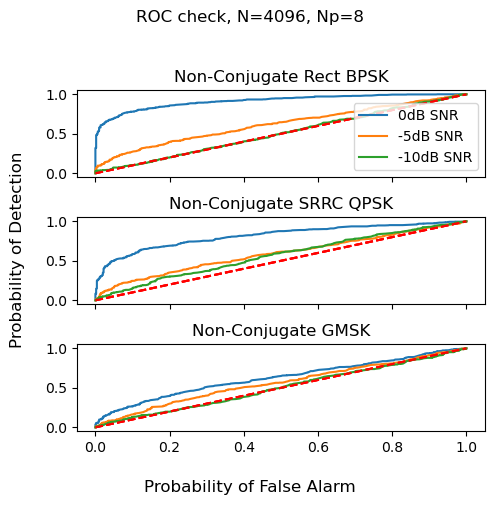

Starting conjugate ROC test for ssca_flat_8...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.475/3
-5dB SNR Score: 1.957/3
-10dB SNR Score: 1.663/3


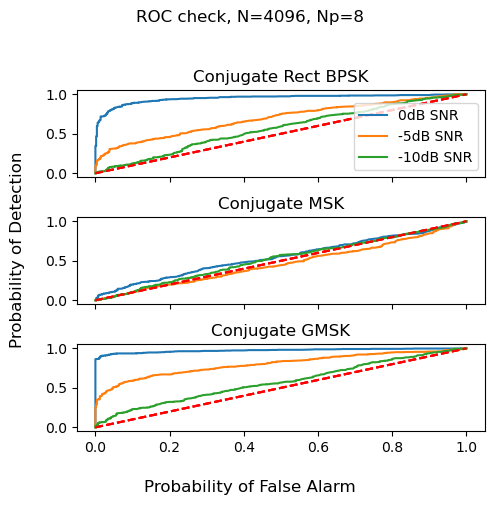

Starting non-conjugate ROC test for fastsc_8...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 1.954/3
-5dB SNR Score: 1.701/3
-10dB SNR Score: 1.491/3


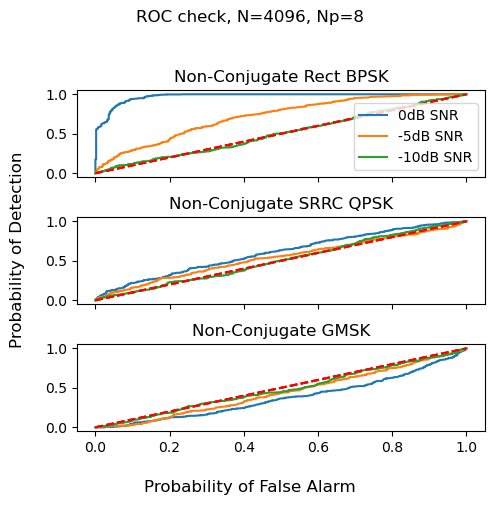

Starting non-conjugate ROC test for fam_16...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.000/3
-5dB SNR Score: 1.821/3
-10dB SNR Score: 1.549/3


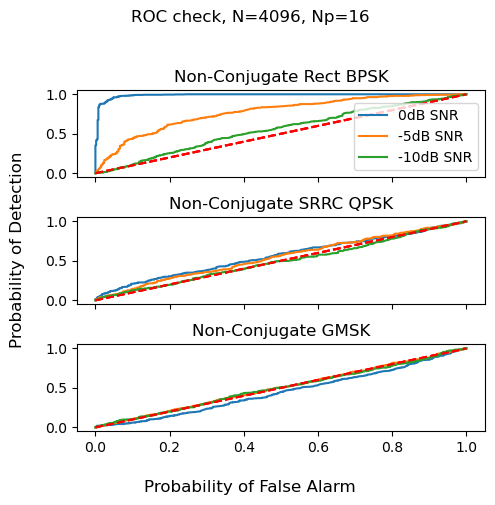

Starting conjugate ROC test for fam_16...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.420/3
-5dB SNR Score: 2.035/3
-10dB SNR Score: 1.656/3


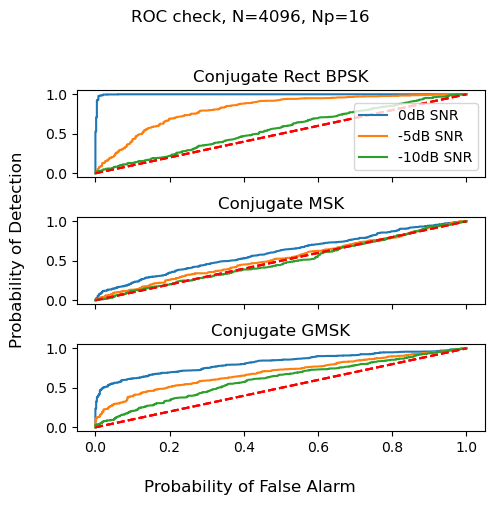

Starting non-conjugate ROC test for ssca_16...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.060/3
-5dB SNR Score: 1.869/3
-10dB SNR Score: 1.629/3


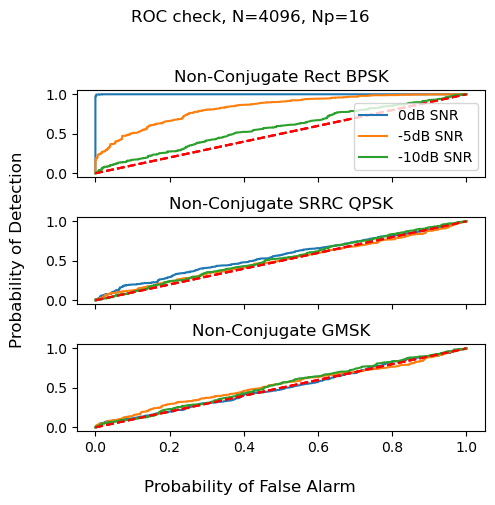

0dB SNR Score: 2.524/3
-5dB SNR Score: 2.185/3
-10dB SNR Score: 1.763/3


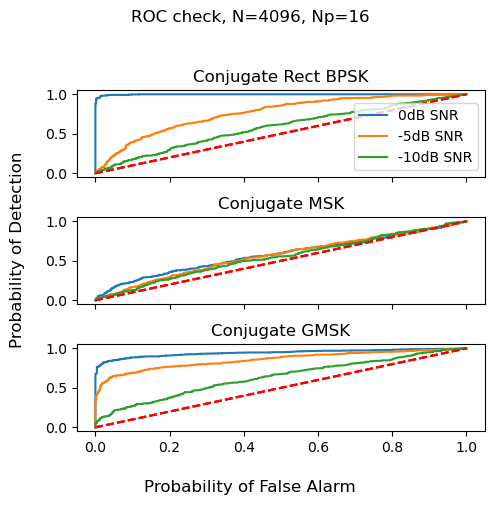

Starting non-conjugate ROC test for fam_flat_16...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.127/3
-5dB SNR Score: 1.898/3
-10dB SNR Score: 1.554/3


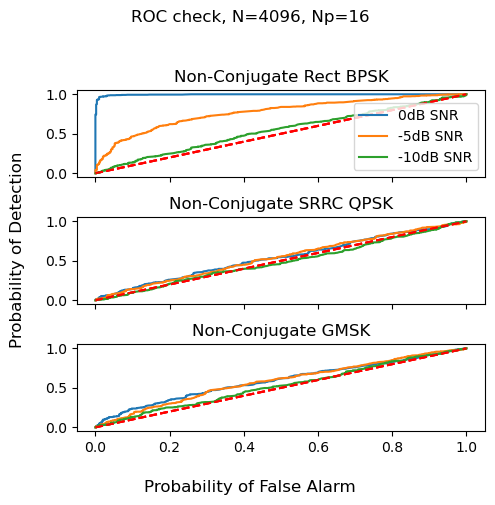

Starting conjugate ROC test for fam_flat_16...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.628/3
-5dB SNR Score: 2.385/3
-10dB SNR Score: 1.770/3


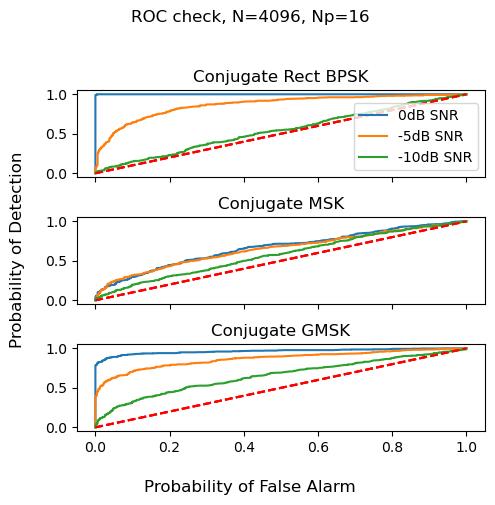

Starting non-conjugate ROC test for ssca_flat_16...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.374/3
-5dB SNR Score: 2.058/3
-10dB SNR Score: 1.593/3


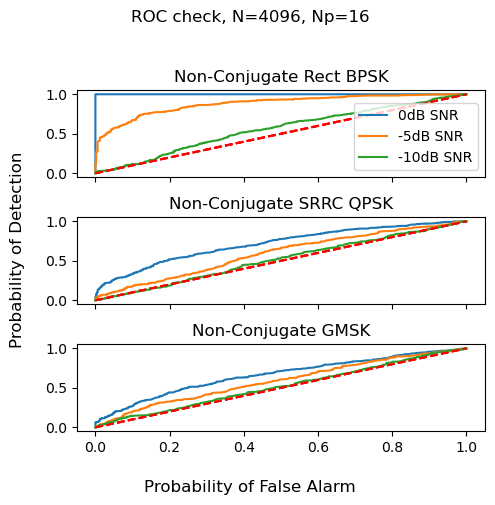

Starting conjugate ROC test for ssca_flat_16...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.630/3
-5dB SNR Score: 2.378/3
-10dB SNR Score: 1.735/3


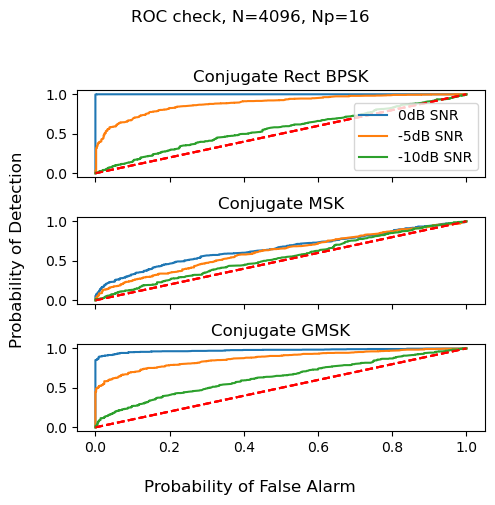

Starting non-conjugate ROC test for fastsc_16...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.052/3
-5dB SNR Score: 1.817/3
-10dB SNR Score: 1.592/3


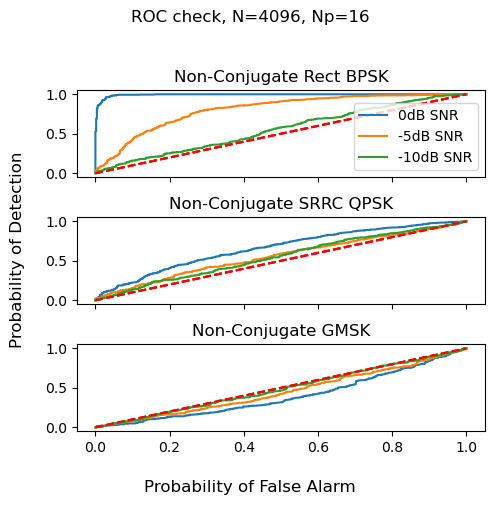

Starting non-conjugate ROC test for fam_32...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 1.898/3
-5dB SNR Score: 1.884/3
-10dB SNR Score: 1.555/3


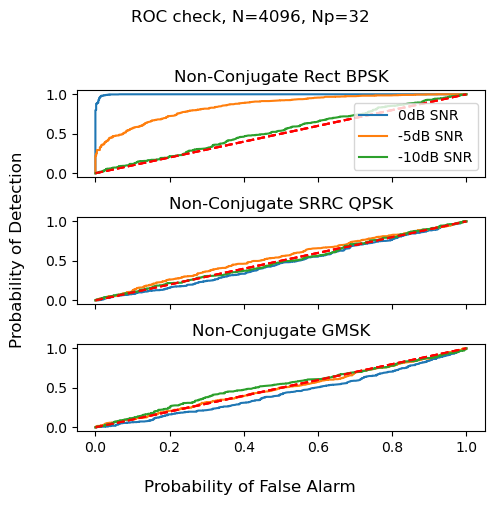

Starting conjugate ROC test for fam_32...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.507/3
-5dB SNR Score: 2.133/3
-10dB SNR Score: 1.735/3


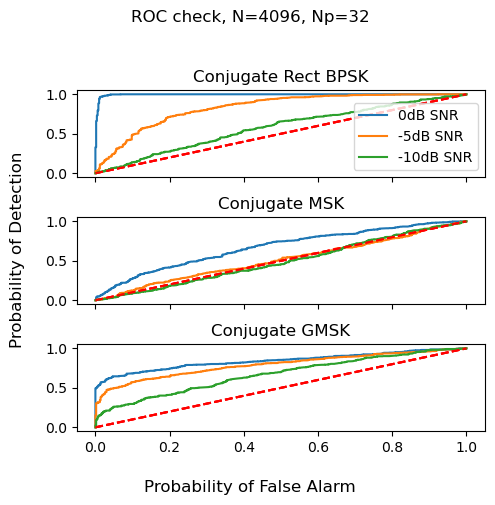

Starting non-conjugate ROC test for ssca_32...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 1.997/3
-5dB SNR Score: 1.912/3
-10dB SNR Score: 1.581/3


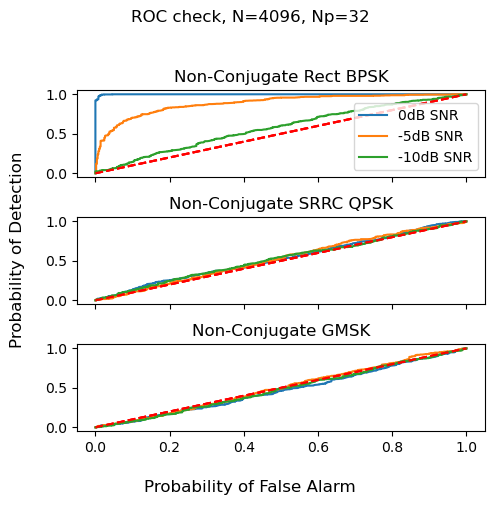

Starting conjugate ROC test for ssca_32...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.611/3
-5dB SNR Score: 2.130/3
-10dB SNR Score: 1.720/3


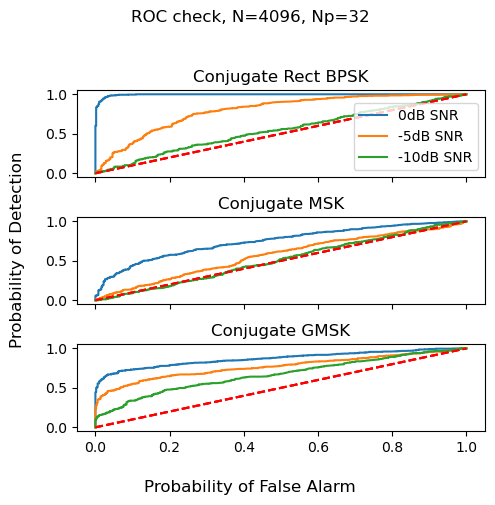

Starting non-conjugate ROC test for fam_flat_32...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.317/3
-5dB SNR Score: 2.003/3
-10dB SNR Score: 1.638/3


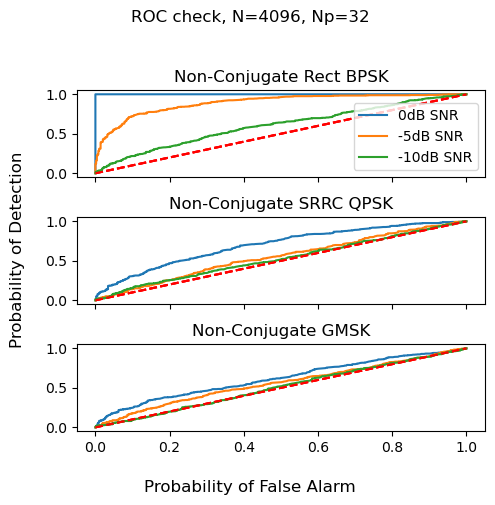

Starting conjugate ROC test for fam_flat_32...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.690/3
-5dB SNR Score: 2.344/3
-10dB SNR Score: 1.750/3


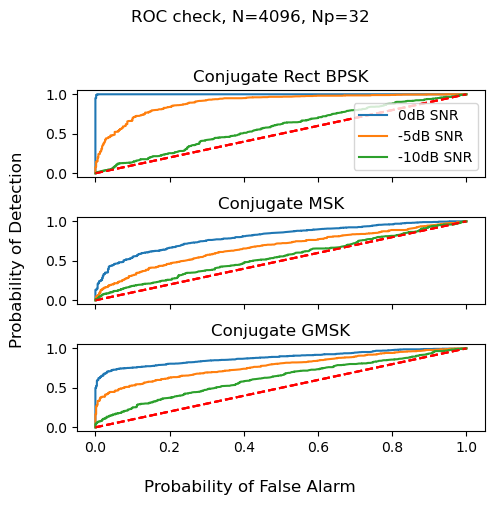

Starting non-conjugate ROC test for ssca_flat_32...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.343/3
-5dB SNR Score: 2.130/3
-10dB SNR Score: 1.604/3


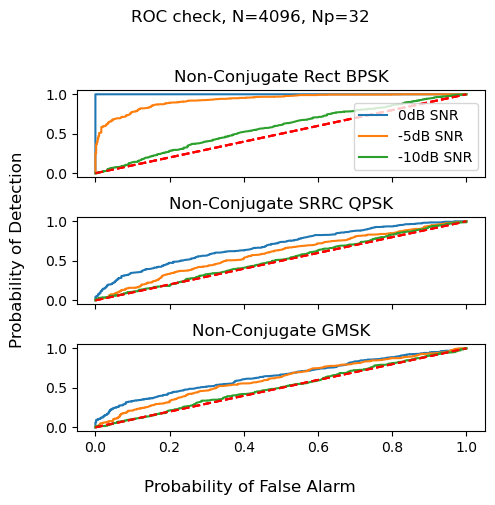

Starting conjugate ROC test for ssca_flat_32...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.733/3
-5dB SNR Score: 2.310/3
-10dB SNR Score: 1.764/3


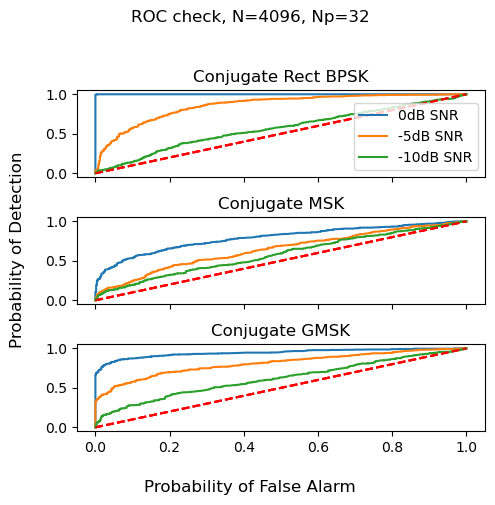

Starting non-conjugate ROC test for fastsc_32...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.050/3
-5dB SNR Score: 1.931/3
-10dB SNR Score: 1.623/3


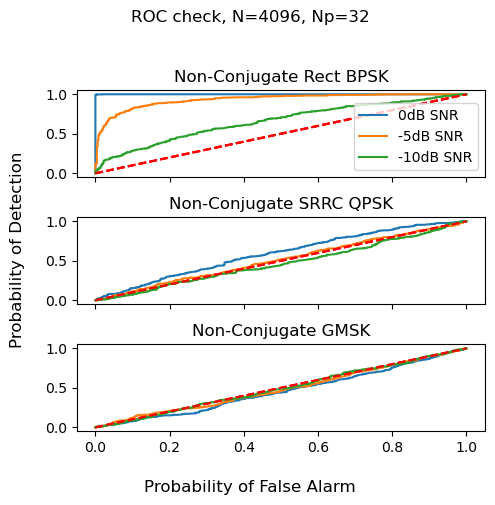

Starting non-conjugate ROC test for fam_64...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 1.987/3
-5dB SNR Score: 1.840/3
-10dB SNR Score: 1.633/3


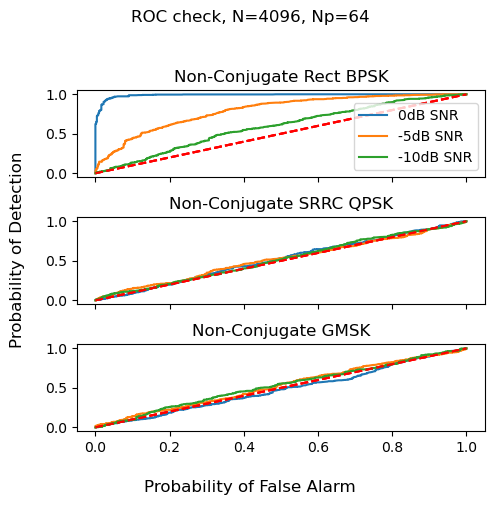

Starting conjugate ROC test for fam_64...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.433/3
-5dB SNR Score: 2.032/3
-10dB SNR Score: 1.736/3


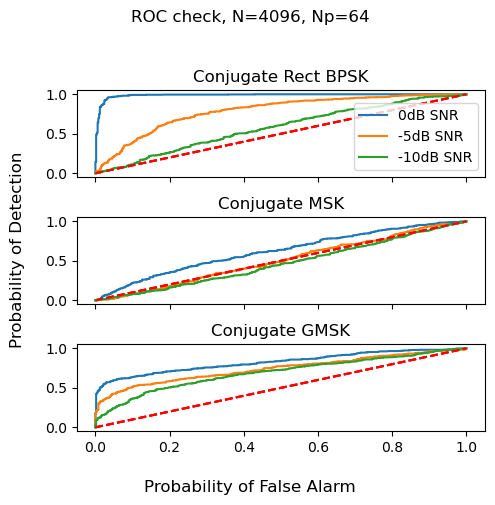

Starting non-conjugate ROC test for ssca_64...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.121/3
-5dB SNR Score: 1.935/3
-10dB SNR Score: 1.572/3


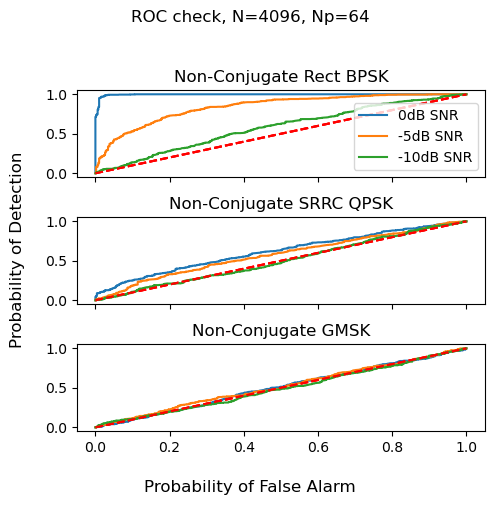

Starting conjugate ROC test for ssca_64...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.555/3
-5dB SNR Score: 2.114/3
-10dB SNR Score: 1.710/3


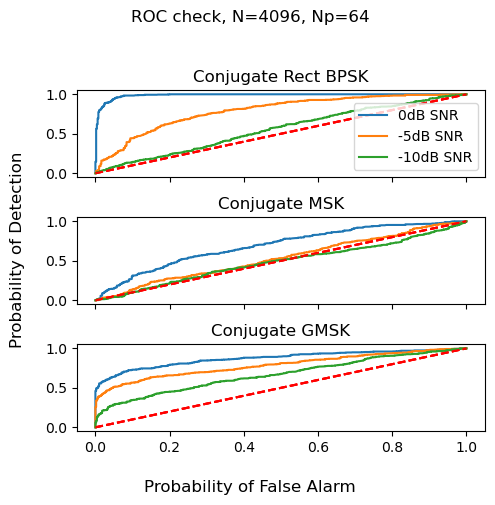

Starting non-conjugate ROC test for fam_flat_64...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.255/3
-5dB SNR Score: 1.967/3
-10dB SNR Score: 1.648/3


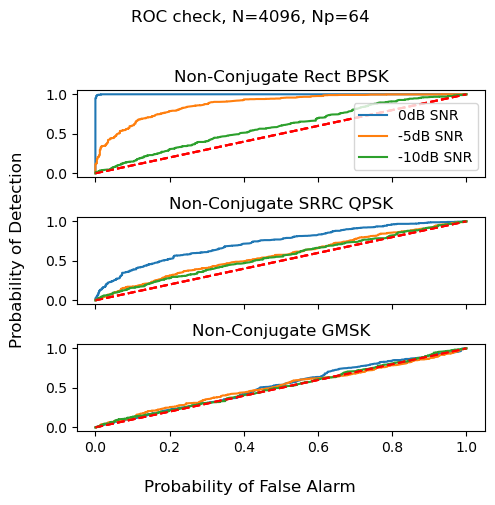

Starting conjugate ROC test for fam_flat_64...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.717/3
-5dB SNR Score: 2.271/3
-10dB SNR Score: 1.749/3


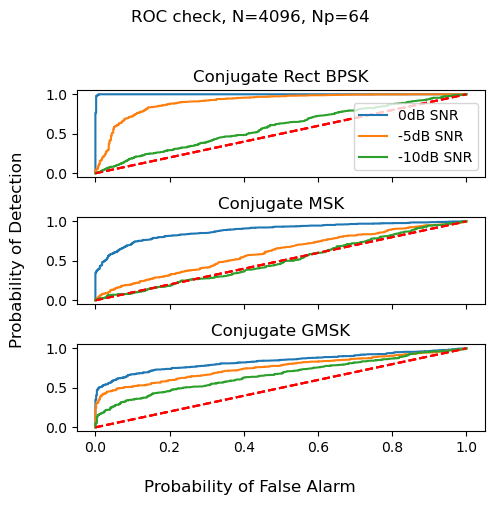

Starting non-conjugate ROC test for ssca_flat_64...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.323/3
-5dB SNR Score: 2.002/3
-10dB SNR Score: 1.608/3


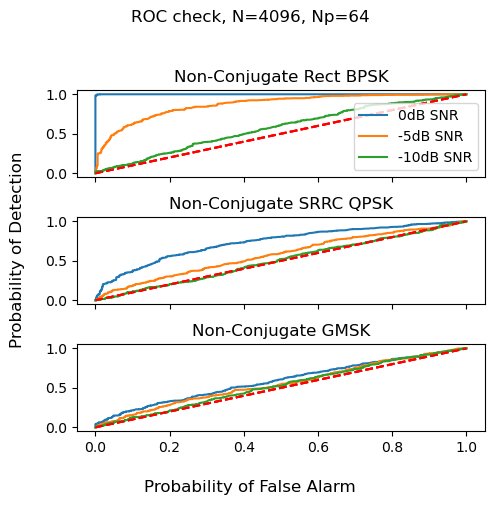

Starting conjugate ROC test for ssca_flat_64...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.793/3
-5dB SNR Score: 2.351/3
-10dB SNR Score: 1.783/3


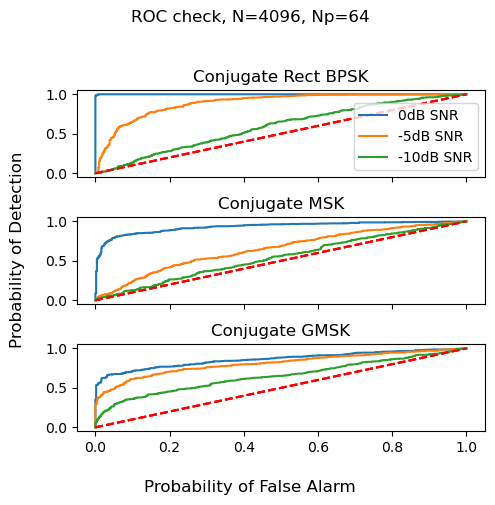

Starting non-conjugate ROC test for fastsc_64...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.529/3
-5dB SNR Score: 2.054/3
-10dB SNR Score: 1.605/3


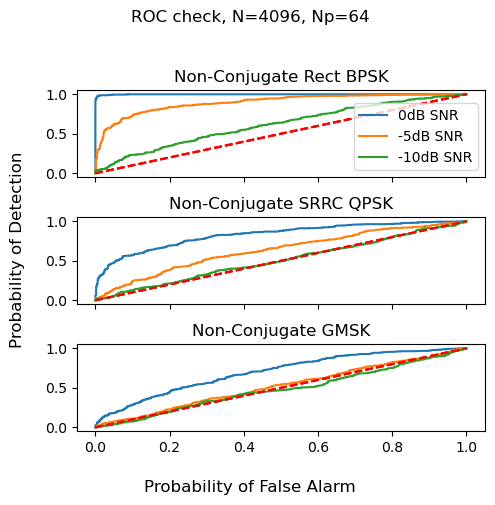

Starting non-conjugate ROC test for fam_128...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.237/3
-5dB SNR Score: 1.758/3
-10dB SNR Score: 1.483/3


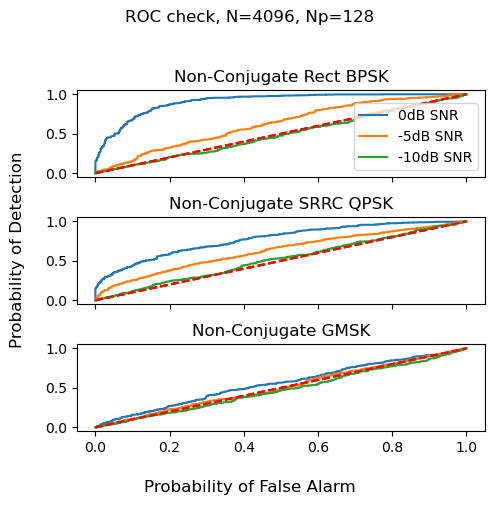

Starting conjugate ROC test for fam_128...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.317/3
-5dB SNR Score: 1.905/3
-10dB SNR Score: 1.624/3


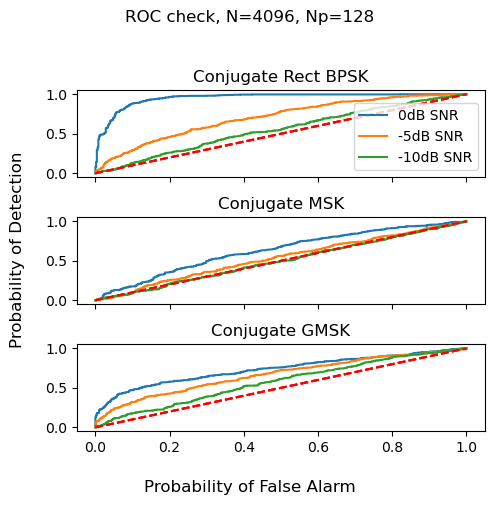

Starting non-conjugate ROC test for ssca_128...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.428/3
-5dB SNR Score: 1.838/3
-10dB SNR Score: 1.537/3


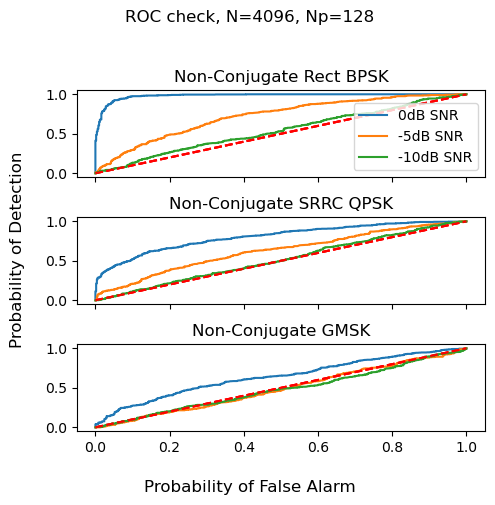

Starting conjugate ROC test for ssca_128...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.323/3
-5dB SNR Score: 1.967/3
-10dB SNR Score: 1.615/3


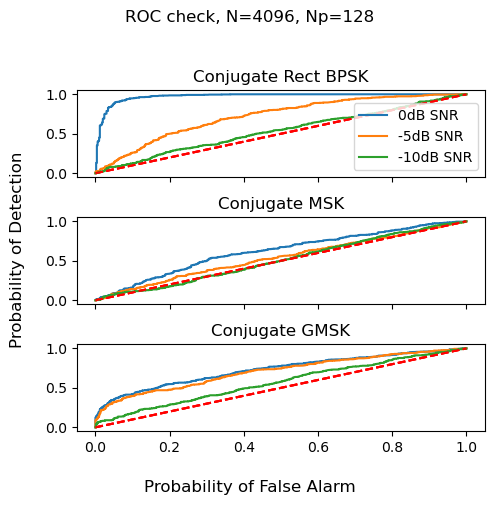

Starting non-conjugate ROC test for fam_flat_128...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.113/3
-5dB SNR Score: 1.687/3
-10dB SNR Score: 1.502/3


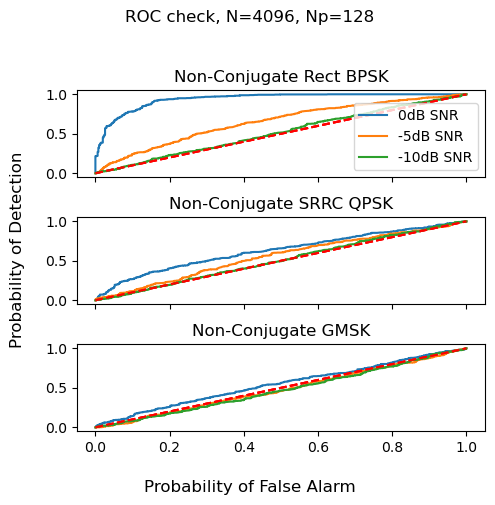

Starting conjugate ROC test for fam_flat_128...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.570/3
-5dB SNR Score: 2.133/3
-10dB SNR Score: 1.640/3


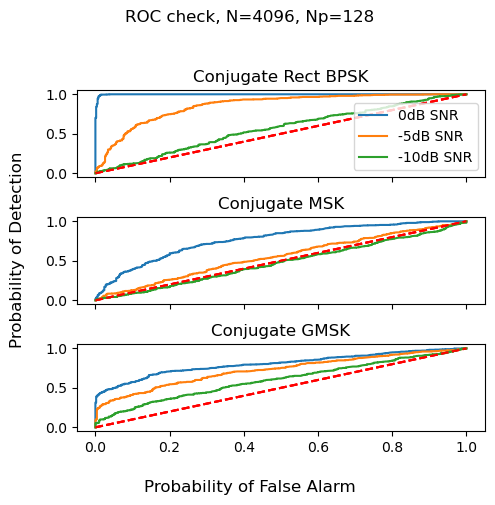

Starting non-conjugate ROC test for ssca_flat_128...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.441/3
-5dB SNR Score: 1.952/3
-10dB SNR Score: 1.580/3


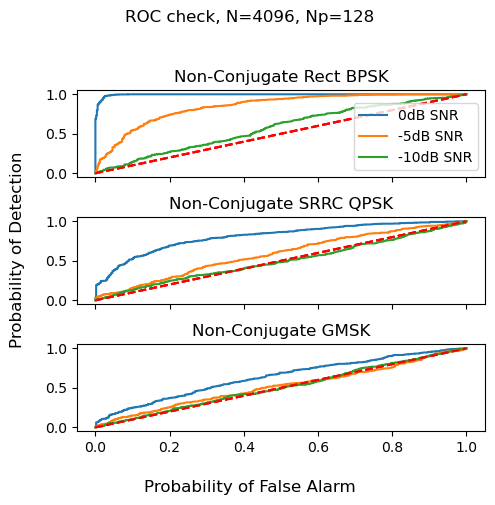

Starting conjugate ROC test for ssca_flat_128...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.567/3
-5dB SNR Score: 2.153/3
-10dB SNR Score: 1.731/3


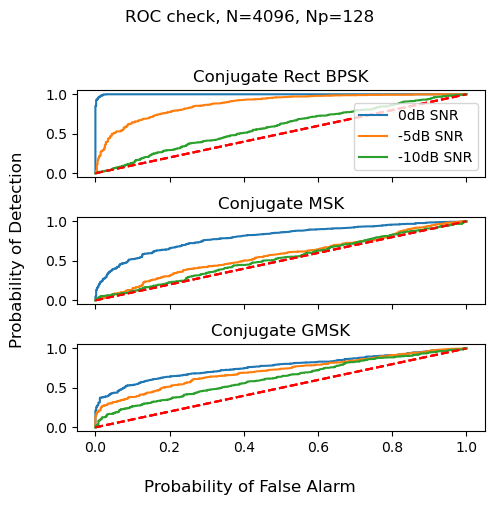

Starting non-conjugate ROC test for fastsc_128...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.884/3
-5dB SNR Score: 2.117/3
-10dB SNR Score: 1.635/3


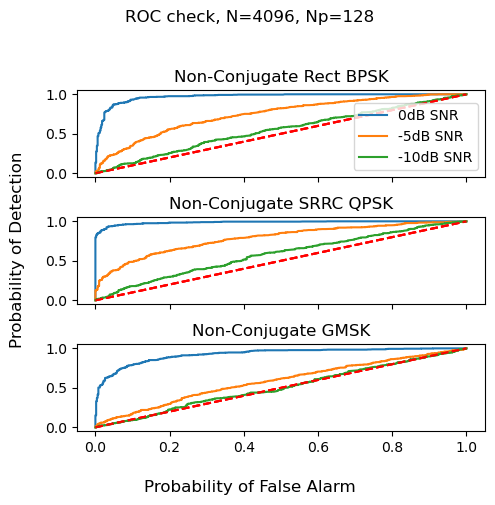

Starting non-conjugate ROC test for fam_256...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.157/3
-5dB SNR Score: 1.711/3
-10dB SNR Score: 1.511/3


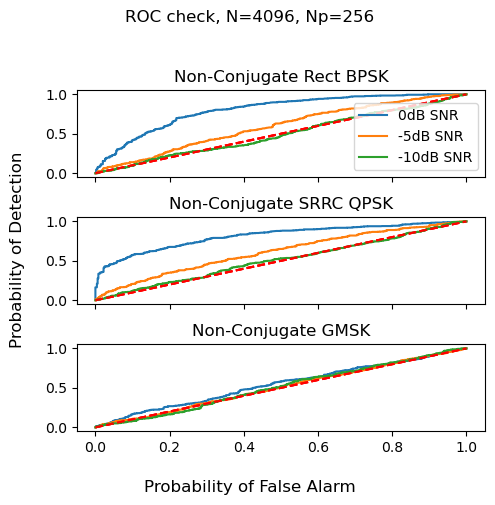

Starting conjugate ROC test for fam_256...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.049/3
-5dB SNR Score: 1.710/3
-10dB SNR Score: 1.575/3


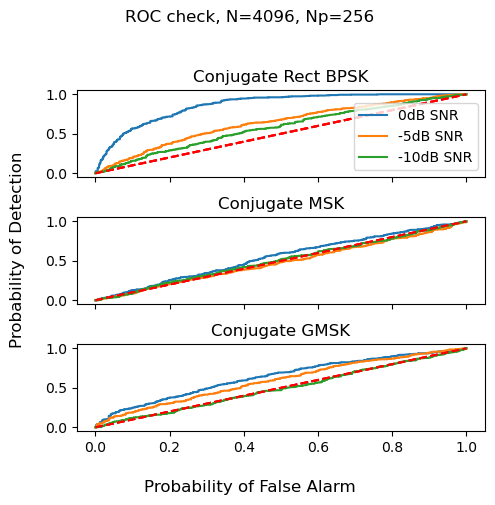

Starting non-conjugate ROC test for ssca_256...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.423/3
-5dB SNR Score: 1.805/3
-10dB SNR Score: 1.493/3


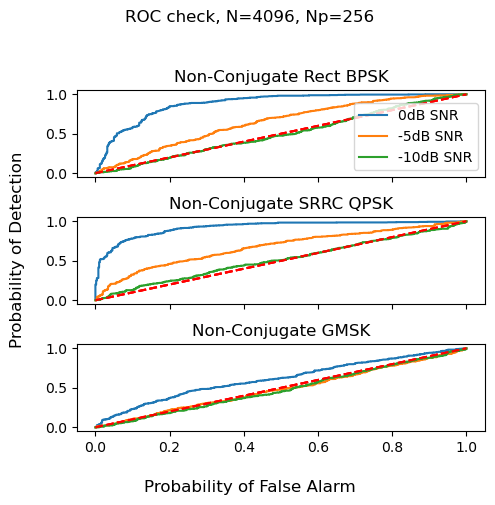

Starting conjugate ROC test for ssca_256...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.126/3
-5dB SNR Score: 1.728/3
-10dB SNR Score: 1.538/3


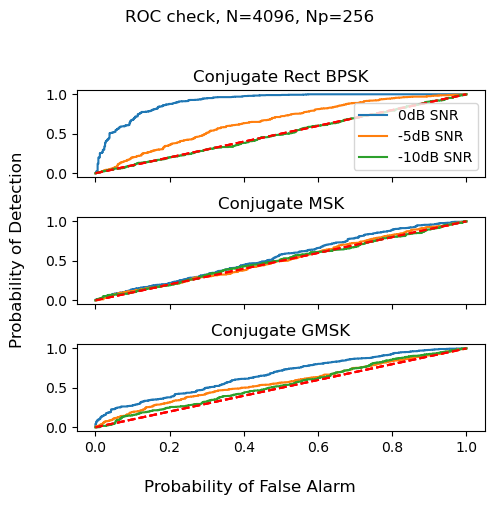

Starting non-conjugate ROC test for fam_flat_256...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.073/3
-5dB SNR Score: 1.648/3
-10dB SNR Score: 1.524/3


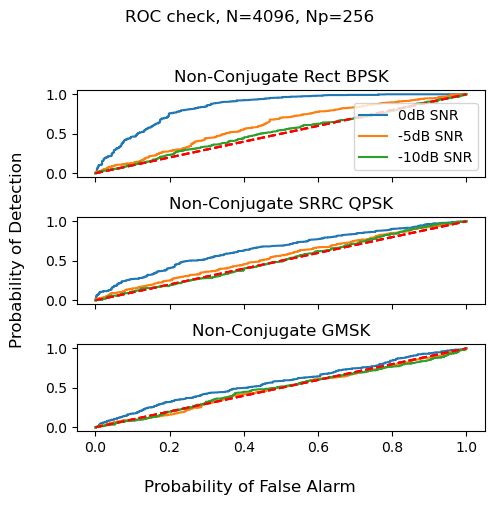

Starting conjugate ROC test for fam_flat_256...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.396/3
-5dB SNR Score: 1.985/3
-10dB SNR Score: 1.621/3


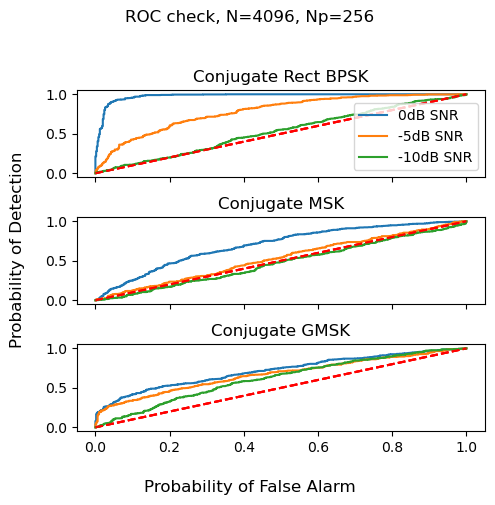

Starting non-conjugate ROC test for ssca_flat_256...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.589/3
-5dB SNR Score: 1.850/3
-10dB SNR Score: 1.567/3


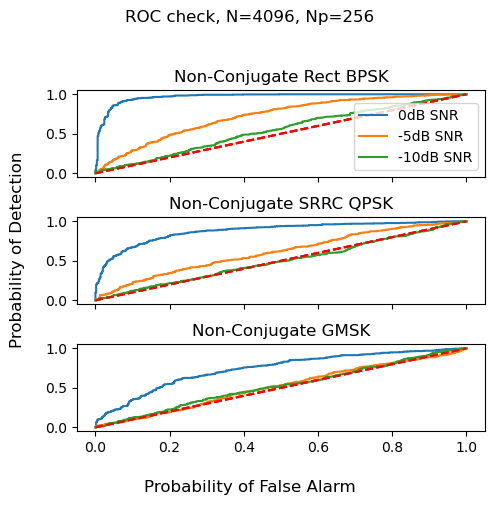

Starting conjugate ROC test for ssca_flat_256...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.470/3
-5dB SNR Score: 2.022/3
-10dB SNR Score: 1.638/3


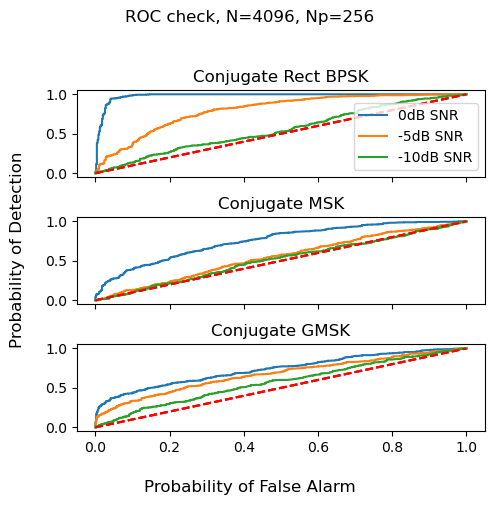

Starting non-conjugate ROC test for fastsc_256...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.722/3
-5dB SNR Score: 2.109/3
-10dB SNR Score: 1.579/3


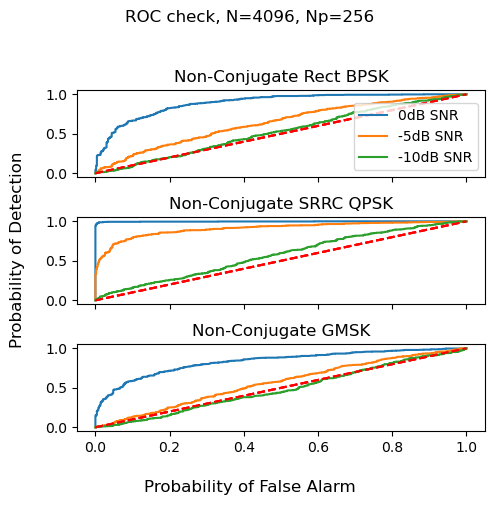

In [9]:
for i in range(len_np):
    _, _, auc_nc_score, _ = test.plot_roc_non_conjugate(fam, Np=Np[i], L=int(Np[i]/4), fam=True, snr=[0, -5, -10], no_of_simulation=500, name=f"fam_{Np[i]}", save=True)
    _, _, auc_c_score, _ = test.plot_roc_conjugate(fam, Np=Np[i], L=int(Np[i]/4), fam=True, snr=[0, -5, -10], no_of_simulation=500, name=f"fam_{Np[i]}", save=True)

    fam_auc_nc_score[i, :] = np.mean(auc_nc_score, axis=1)
    fam_auc_c_score[i, :] = np.mean(auc_c_score, axis=1)

    _, _, auc_nc_score, _ = test.plot_roc_non_conjugate(ssca, Np=Np[i], snr=[0, -5, -10], no_of_simulation=500, name=f"ssca_{Np[i]}", save=True)
    _, _, auc_c_score, _ = test.plot_roc_conjugate(ssca, Np=Np[i], snr=[0, -5, -10], no_of_simulation=500, name=f"ssca_{Np[i]}", save=True)

    ssca_auc_nc_score[i, :] = np.mean(auc_nc_score, axis=1)
    ssca_auc_c_score[i, :] = np.mean(auc_c_score, axis=1)

    _, _, auc_nc_score, _ = test.plot_roc_non_conjugate(fam_flattop, Np=Np[i], L=int(Np[i]/8), no_of_simulation=500, fam=True, snr=[0, -5, -10], name=f"fam_flat_{Np[i]}", save=True)
    _, _, auc_c_score, _ = test.plot_roc_conjugate(fam_flattop, Np=Np[i], L=int(Np[i]/8), no_of_simulation=500, fam=True, snr=[0, -5, -10], name=f"fam_flat_{Np[i]}", save=True)

    fam_flat_auc_nc_score[i, :] = np.mean(auc_nc_score, axis=1)
    fam_flat_auc_c_score[i, :] = np.mean(auc_c_score, axis=1)

    _, _, auc_nc_score, _ = test.plot_roc_non_conjugate(ssca_flattop, Np=Np[i], snr=[0, -5, -10], no_of_simulation=500, name=f"ssca_flat_{Np[i]}", save=True)
    _, _, auc_c_score, _ = test.plot_roc_conjugate(ssca_flattop, Np=Np[i], snr=[0, -5, -10], no_of_simulation=500, name=f"ssca_flat_{Np[i]}", save=True)

    ssca_flat_auc_nc_score[i, :] = np.mean(auc_nc_score, axis=1)
    ssca_flat_auc_c_score[i, :] = np.mean(auc_c_score, axis=1)

    _, _, auc_nc_score, _ = test.plot_roc_non_conjugate(fast_sc_wrapper, Np=Np[i], snr=[0, -5, -10], no_of_simulation=500, name=f"fastsc_{Np[i]}", save=True)

    fastsc_auc_nc_score[i, :] = np.mean(auc_nc_score, axis=1)



In [4]:
def scf_2d_fft_hamm(signal, Np=64, fs=1, conjugate=False, coherence=False, window_1="hamming", window_2=None):
    Sx, f, alpha = scf_2d_fft(signal, max_lag=Np, fs=fs, conjugate=conjugate, window=window_1)

    N = len(signal)
    
     # Optional spectral coherence calculation from SSCA SCF
    if coherence:
        sample_1 = np.rint((f + alpha/2) * Np/fs).astype(int)
        if conjugate:
            sample_2 = np.rint((alpha/2 - f) * Np/fs).astype(int)
        else:
            sample_2 = np.rint((f - alpha/2) * Np/fs).astype(int)

        psd_tsm = np.fft.ifftshift(psd(signal, L=Np, method="welch", db=False, plot=False))

        coherence_denominator = np.sqrt(psd_tsm[sample_1] * psd_tsm[sample_2])

        Sx = Sx/coherence_denominator

    return np.abs(Sx), f, alpha

In [5]:
def scf_2d_fft_flattop(signal, Np=64, fs=1, conjugate=False, coherence=False, window_1="flattop", window_2=None):
    Sx, f, alpha = scf_2d_fft(signal, max_lag=Np, fs=fs, conjugate=conjugate, window=window_1)

    N = len(signal)
    
     # Optional spectral coherence calculation from SSCA SCF
    if coherence:
        sample_1 = np.rint((f + alpha/2) * Np/fs).astype(int)
        if conjugate:
            sample_2 = np.rint((alpha/2 - f) * Np/fs).astype(int)
        else:
            sample_2 = np.rint((f - alpha/2) * Np/fs).astype(int)

        psd_tsm = np.fft.ifftshift(psd(signal, L=Np, method="welch", db=False, plot=False))

        coherence_denominator = np.sqrt(psd_tsm[sample_1] * psd_tsm[sample_2])

        Sx = Sx/coherence_denominator

    return np.abs(Sx), f, alpha

Starting non-conjugate ROC test...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.579/3
-5dB SNR Score: 2.039/3
-10dB SNR Score: 1.632/3


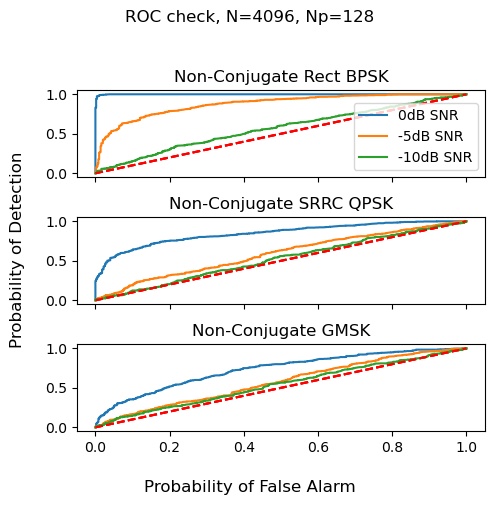

Starting conjugate ROC test...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.752/3
-5dB SNR Score: 2.294/3
-10dB SNR Score: 1.726/3


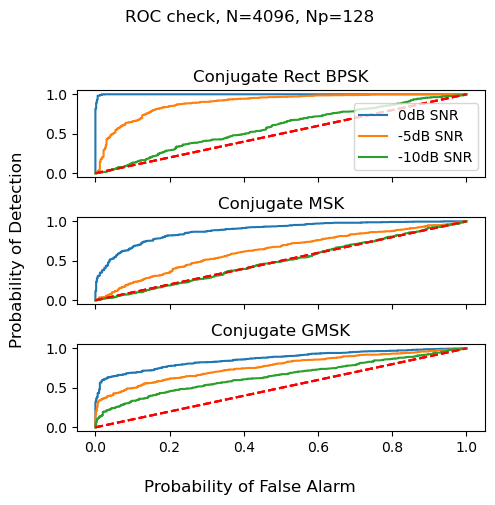

Starting non-conjugate ROC test...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.696/3
-5dB SNR Score: 1.930/3
-10dB SNR Score: 1.567/3


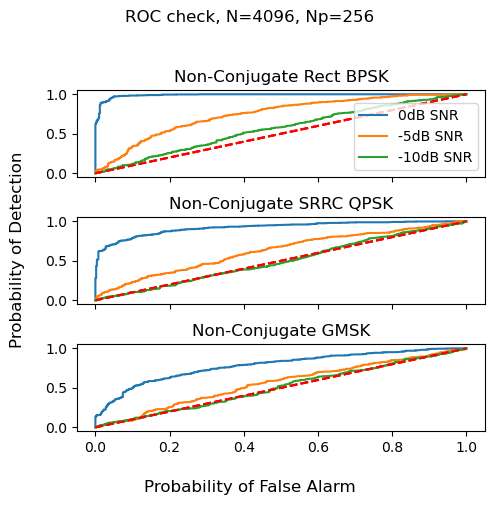

Starting conjugate ROC test...
  Rect BPSK cycle frequency: α = 0.5000
  MSK cycle frequency:       α = 0.2500
  GMSK cycle frequency:      α = 0.1500
0dB SNR Score: 2.581/3
-5dB SNR Score: 2.089/3
-10dB SNR Score: 1.680/3


In [ ]:
for i in range(4, len_np):
    # _, _, auc_nc_score, _ = test.plot_roc_non_conjugate(scf_2d_fft_hamm, Np=Np[i], snr=[0, -5, -10], no_of_simulation=500, name=f"scf_2d_fft_{Np[i]}", save=True)
    # _, _, auc_c_score, _ = test.plot_roc_conjugate(scf_2d_fft_hamm, Np=Np[i], snr=[0, -5, -10], no_of_simulation=500, name=f"scf_2d_fft_{Np[i]}", save=True)

    # scf_2d_fft_auc_nc_score[i, :] = np.mean(auc_nc_score, axis=1)
    # scf_2d_fft_auc_c_score[i, :] = np.mean(auc_c_score, axis=1)

    _, _, auc_nc_score, _ = test.plot_roc_non_conjugate(scf_2d_fft_flattop, Np=Np[i], snr=[0, -5, -10], no_of_simulation=500, name=f"scf_2d_fft_flat_{Np[i]}", save=True)
    _, _, auc_c_score, _ = test.plot_roc_conjugate(scf_2d_fft_flattop, Np=Np[i], snr=[0, -5, -10], no_of_simulation=500, name=f"scf_2d_fft_flat_{Np[i]}", save=True)

    scf_2d_fft_flat_auc_nc_score[i, :] = np.mean(auc_nc_score, axis=1)
    scf_2d_fft_flat_auc_c_score[i, :] = np.mean(auc_c_score, axis=1)

In [3]:
def fast_sc_flat_wrapper(signal, Np=64, conjugate=False, coherence=False, window="flattop"):
    if coherence:
        opt = {"abs": 0, "calib": 1, "coh": 1}
    else:
        opt = {"abs": 0, "calib": 1, "coh": 0}

    Sx, alpha, f, _, _, _ = Fast_SC(signal, Nw=Np, alpha_max=0.5, Fs=1, opt=opt, WindowType=window)

    alpha, f = np.meshgrid(alpha, f)

    return np.abs(Sx), f, alpha

Starting non-conjugate ROC test...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 1.962/3
-5dB SNR Score: 1.647/3
-10dB SNR Score: 1.492/3


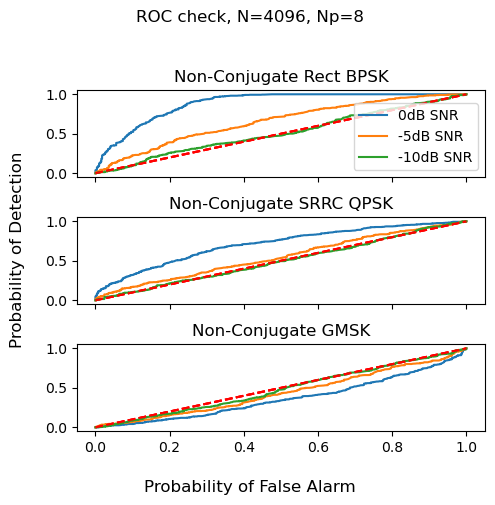

Starting non-conjugate ROC test...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 1.908/3
-5dB SNR Score: 1.589/3
-10dB SNR Score: 1.498/3


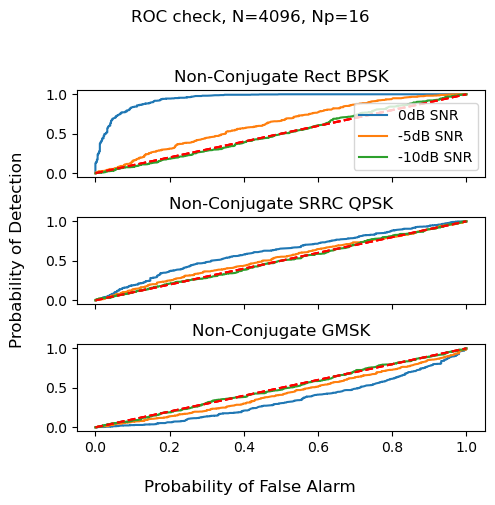

Starting non-conjugate ROC test...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 1.900/3
-5dB SNR Score: 1.778/3
-10dB SNR Score: 1.575/3


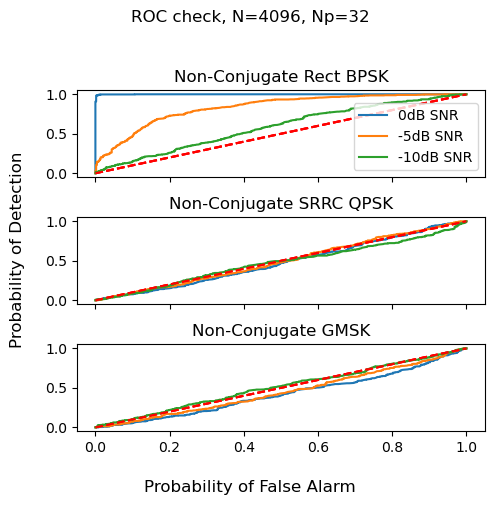

Starting non-conjugate ROC test...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.077/3
-5dB SNR Score: 1.900/3
-10dB SNR Score: 1.595/3


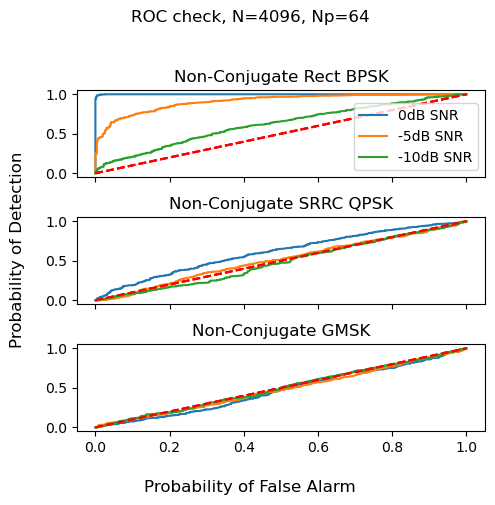

Starting non-conjugate ROC test...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000


KeyboardInterrupt: 

In [5]:
for i in range(len_np):
    _, _, auc_nc_score, _ = test.plot_roc_non_conjugate(fast_sc_flat_wrapper, Np=Np[i], snr=[0, -5, -10], no_of_simulation=500, name=f"fastsc_flat_{Np[i]}", save=True)

    fastsc_flat_auc_nc_score[i, :] = np.mean(auc_nc_score, axis=1)


In [8]:
fam_64_nc_score = np.load("data/roc_test_fam_64_score_non_conjugate.npy")
fam_64_c_score = np.load("data/roc_test_fam_64_score_conjugate.npy")

ssca_64_nc_score = np.load("data/roc_test_ssca_64_score_non_conjugate.npy")
ssca_64_c_score = np.load("data/roc_test_ssca_64_score_conjugate.npy")

fam_flat_64_nc_score = np.load("data/roc_test_fam_flat_64_score_non_conjugate.npy")
fam_flat_64_c_score = np.load("data/roc_test_fam_flat_64_score_conjugate.npy")

ssca_flat_64_nc_score = np.load("data/roc_test_ssca_flat_64_score_non_conjugate.npy")
ssca_flat_64_c_score = np.load("data/roc_test_ssca_flat_64_score_conjugate.npy")

fastsc_64_nc_score = np.load("data/roc_test_fastsc_64_score_non_conjugate.npy")

scf_2d_fft_flat_nc_score = np.load("data/roc_test_scf_2d_fft_flat_64_score_non_conjugate.npy")
scf_2d_fft_flat_c_score =  np.load("data/roc_test_scf_2d_fft_flat_64_score_conjugate.npy")

scf_2d_fft_nc_score = np.load("data/roc_test_scf_2d_fft_64_score_non_conjugate.npy")
scf_2d_fft_c_score = np.load("data/roc_test_scf_2d_fft_64_score_conjugate.npy")


In [10]:
import matplotlib.pyplot as plt

[1.987 1.84  1.633 2.121 1.935 1.572 2.255 1.967 1.648 2.323 2.002 1.608
 2.529 2.054 1.605 2.62  2.028 1.619 2.543 2.088 1.657]


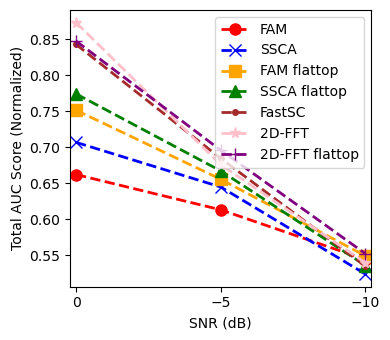

In [11]:
scores_nc = np.concatenate((fam_64_nc_score, ssca_64_nc_score, fam_flat_64_nc_score, ssca_flat_64_nc_score, fastsc_64_nc_score, scf_2d_fft_nc_score, scf_2d_fft_flat_nc_score), axis=0)

print(scores_nc)

snr_labels = ['0 dB', '-5 dB', '-10 dB']
signal_labels = ['FAM', 'SSCA', 'FAM flattop', 'SSCA flattop', 'FastSC', '2D-FFT', '2D-FFT flattop']
snr = [0, -5, -10]
fig = plt.figure(figsize=(4,3.5))
plt.xlim(0.2, -10.2)
plt.xticks(snr, label=snr_labels)

colors = ['red', 'blue', 'orange', 'green', 'brown', 'pink', 'purple']

# Plot one line for each signal type
markers = ['o', 'x', 's', '^', '.', '*', '+'] # Circle, Square, Triangle

for i in range(7):
    plt.plot(snr, scores_nc[i*3:i*3+3] / 3, 
            label=signal_labels[i], 
            marker=markers[i], 
            linestyle='--',
            color=colors[i],
            linewidth=2,
            markersize=8)

plt.xlabel("SNR (dB)")
plt.ylabel("Total AUC Score (Normalized)")
plt.legend()
plt.tight_layout()
plt.savefig("fig/roc_compare_nc.png")

[2.433 2.032 1.736 2.555 2.114 1.71  2.717 2.271 1.749 2.793 2.351 1.783
 2.733 2.272 1.742 2.866 2.413 1.807]


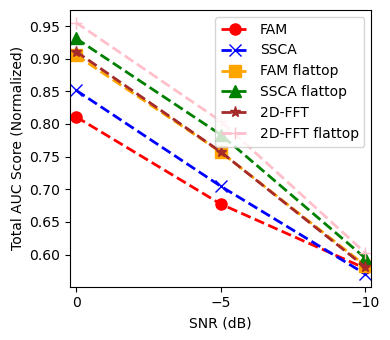

In [16]:
scores_c = np.concatenate((fam_64_c_score, ssca_64_c_score, fam_flat_64_c_score, ssca_flat_64_c_score, scf_2d_fft_c_score, scf_2d_fft_flat_c_score), axis=0)

print(scores_c)

signal_labels = ['FAM', 'SSCA', 'FAM flattop', 'SSCA flattop', 'FastSC', '2D-FFT', '2D-FFT flattop']

snr_labels = ['0 dB', '-5 dB', '-10 dB']
signal_labels = ['FAM', 'SSCA', 'FAM flattop', 'SSCA flattop', '2D-FFT', '2D-FFT flattop']
snr = [0, -5, -10]
fig = plt.figure(figsize=(4,3.5))
plt.xlim(0.2, -10.2)
plt.xticks(snr, label=snr_labels)

# Plot one line for each signal type
markers = ['o', 'x', 's', '^', '*', '+'] # Circle, Square, Triangle

for i in range(6):
    plt.plot(snr, scores_c[i*3:i*3+3] / 3, 
            label=signal_labels[i], 
            marker=markers[i], 
            linestyle='--',
            color=colors[i],
            linewidth=2,
            markersize=8)

plt.xlabel("SNR (dB)")
plt.ylabel("Total AUC Score (Normalized)")
plt.legend()
plt.tight_layout()
plt.savefig("fig/roc_compare_c.png")

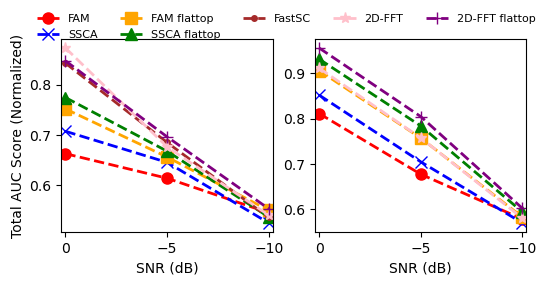

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))  # ~full textwidth for both panels
axes[0].set_xlim(0.2, -10.2)
axes[0].set_xticks(snr)

signal_labels = ['FAM', 'SSCA', 'FAM flattop', 'SSCA flattop', 'FastSC', '2D-FFT', '2D-FFT flattop']
colors = ['red', 'blue', 'orange', 'green', 'brown', 'pink', 'purple']
markers = ['o', 'x', 's', '^', '.', '*', '+'] # Circle, Square, Triangle


for i in range(7):
    axes[0].plot(snr, scores_nc[i*3:i*3+3] / 3, 
            label=signal_labels[i], 
            marker=markers[i], 
            linestyle='--',
            color=colors[i],
            linewidth=2,
            markersize=8)

axes[0].set_xlabel("SNR (dB)")
axes[0].set_ylabel("Total AUC Score (Normalized)")

axes[1].set_xlim(0.2, -10.2)
axes[1].set_xticks(snr)

signal_labels = ['FAM', 'SSCA', 'FAM flattop', 'SSCA flattop', '2D-FFT', '2D-FFT flattop']
colors = ['red', 'blue', 'orange', 'green', 'pink', 'purple']
markers = ['o', 'x', 's', '^', '*', '+'] # Circle, Square, Triangle

for i in range(6):
    axes[1].plot(snr, scores_c[i*3:i*3+3] / 3, 
            label=signal_labels[i], 
            marker=markers[i], 
            linestyle='--',
            color=colors[i],
            linewidth=2,
            markersize=8)

axes[1].set_xlabel("SNR (dB)")

# After plotting both subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', 
           ncol=5, fontsize=8, bbox_to_anchor=(0.5, 1.02),
           frameon=False)

plt.savefig("fig/roc_compare_subplot.png", dpi=300, bbox_inches='tight')

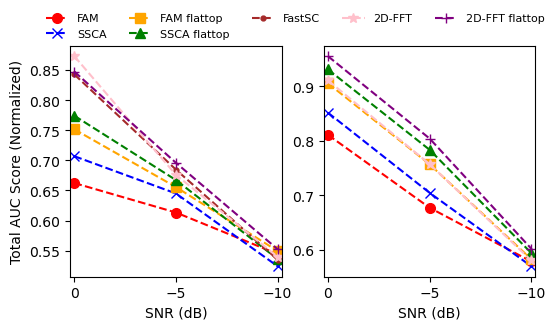

In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(6, 3))  # ~full textwidth for both panels

# --- Left Plot ---
axes[0].set_xlim(0.2, -10.2)
axes[0].set_xticks(snr)

signal_labels = ['FAM', 'SSCA', 'FAM flattop', 'SSCA flattop', 'FastSC', '2D-FFT', '2D-FFT flattop']
colors = ['red', 'blue', 'orange', 'green', 'brown', 'pink', 'purple']
markers = ['o', 'x', 's', '^', '.', '*', '+'] 

for i in range(7):
    axes[0].plot(snr, scores_nc[i*3:i*3+3] / 3, 
            label=signal_labels[i], 
            marker=markers[i], 
            linestyle='--',
            color=colors[i],
            linewidth=1.5,
            markersize=7) # <-- Reduced from 8 to 4

axes[0].set_xlabel("SNR (dB)")
axes[0].set_ylabel("Total AUC Score (Normalized)")


# --- Right Plot ---
axes[1].set_xlim(0.2, -10.2)
axes[1].set_xticks(snr)

signal_labels = ['FAM', 'SSCA', 'FAM flattop', 'SSCA flattop', '2D-FFT', '2D-FFT flattop']
colors = ['red', 'blue', 'orange', 'green', 'pink', 'purple']
markers = ['o', 'x', 's', '^', '*', '+'] 

for i in range(6):
    axes[1].plot(snr, scores_c[i*3:i*3+3] / 3, 
            label=signal_labels[i], 
            marker=markers[i], 
            linestyle='--',
            color=colors[i],
            linewidth=1.5,
            markersize=7) # <-- Reduced from 8 to 4

axes[1].set_xlabel("SNR (dB)")

# --- Legend and Save ---
# After plotting both subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', 
           ncol=5, fontsize=8, bbox_to_anchor=(0.5, 1.02),
           frameon=False)

plt.savefig("fig/roc_compare_subplot_rev_1.png", dpi=300, bbox_inches='tight')

In [44]:
df_time = pd.read_csv("data/csv/fam_ssca_fastsc_famf_bench.csv")
df_2d_fft = pd.read_csv("data/csv/scf_2d_fft.csv")

df_time.head()

,Unnamed: 0,name,group,min,max,mean,stddev,rounds,median,iqr,...,stddev_outliers,outliers,ld15iqr,hd15iqr,ops,total,data,iterations,algorithm,Np
0,0,test_ssca[8],NaN,0.001966,0.003038,0.002093,0.000150,244,0.002044,0.000102,...,29,29;22,0.001966,0.002279,477.729111,0.510750,"[0.0027320999943185598, 0.002494600019417703, ...",1,ssca,8
1,7,test_fam[8],NaN,0.006352,0.009453,0.007366,0.000338,116,0.007309,0.000311,...,20,20;7,0.006835,0.008023,135.755492,0.854477,"[0.008023300004424527, 0.007723000016994774, 0...",1,fam_flattop,8
2,1,test_ssca[16],NaN,0.006726,0.016082,0.007216,0.001185,108,0.006906,0.000312,...,5,5;12,0.006726,0.007622,138.581251,0.779326,"[0.007784100016579032, 0.007691999984672293, 0...",1,ssca,16
3,8,test_fam[16],NaN,0.010132,0.026390,0.011488,0.002353,82,0.010811,0.000610,...,6,6;11,0.010132,0.012127,87.050856,0.941978,"[0.011287000001175329, 0.010810700012370944, 0...",1,fam_flattop,16
4,9,test_fam[32],NaN,0.016056,0.019668,0.016697,0.000697,56,0.016503,0.000603,...,7,7;4,0.016056,0.018061,59.889961,0.935048,"[0.0180607000074815, 0.01755560000310652, 0.01...",1,fam_flattop,32


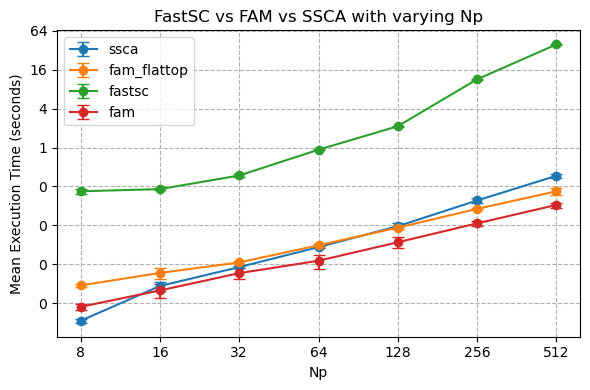

In [42]:
test.plot_benchmark(df_time, param_name='Np', title="FastSC vs FAM vs SSCA with varying Np", xlabel="Np", 
                   log_x=True, log_y=True, figsize=(6, 4), save_path=None)

C:\Users\vngu6249\AppData\Local\Temp\ipykernel_13056\4107043390.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['algorithm'] = pd.Categorical(df_filtered['algorithm'], categories=order, ordered=True)


Figure saved to: fig/all_algo_benchmark.png


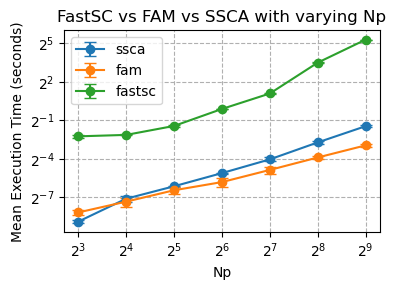

In [10]:
df_filtered = df_time[df_time['algorithm'] != 'fam_flattop']

order = ['ssca', 'fam', 'fastsc']
df_filtered['algorithm'] = pd.Categorical(df_filtered['algorithm'], categories=order, ordered=True)
df_filtered = df_filtered.sort_values(['algorithm', 'Np'])


test.plot_benchmark(df_filtered, param_name='Np', title="FastSC vs FAM vs SSCA with varying Np", xlabel="Np", 
                   log_x=True, log_y=True, figsize=(4, 3), save_path="fig/all_algo_benchmark.png")

In [50]:
df_merged = pd.concat([df_time, df_2d_fft], axis=0)

df_merged.head()

,Unnamed: 0,name,group,min,max,mean,stddev,rounds,median,iqr,...,stddev_outliers,outliers,ld15iqr,hd15iqr,ops,total,data,iterations,algorithm,Np
0,0,test_ssca[8],NaN,0.001966,0.003038,0.002093,0.000150,244,0.002044,0.000102,...,29,29;22,0.001966,0.002279,477.729111,0.510750,"[0.0027320999943185598, 0.002494600019417703, ...",1,ssca,8
1,7,test_fam[8],NaN,0.006352,0.009453,0.007366,0.000338,116,0.007309,0.000311,...,20,20;7,0.006835,0.008023,135.755492,0.854477,"[0.008023300004424527, 0.007723000016994774, 0...",1,fam_flattop,8
2,1,test_ssca[16],NaN,0.006726,0.016082,0.007216,0.001185,108,0.006906,0.000312,...,5,5;12,0.006726,0.007622,138.581251,0.779326,"[0.007784100016579032, 0.007691999984672293, 0...",1,ssca,16
3,8,test_fam[16],NaN,0.010132,0.026390,0.011488,0.002353,82,0.010811,0.000610,...,6,6;11,0.010132,0.012127,87.050856,0.941978,"[0.011287000001175329, 0.010810700012370944, 0...",1,fam_flattop,16
4,9,test_fam[32],NaN,0.016056,0.019668,0.016697,0.000697,56,0.016503,0.000603,...,7,7;4,0.016056,0.018061,59.889961,0.935048,"[0.0180607000074815, 0.01755560000310652, 0.01...",1,fam_flattop,32


In [51]:
df_merged.tail()

,Unnamed: 0,name,group,min,max,mean,stddev,rounds,median,iqr,...,stddev_outliers,outliers,ld15iqr,hd15iqr,ops,total,data,iterations,algorithm,Np
2,2,test_scf_2d_fft[32],NaN,1.995589,2.232118,2.155155,0.036764,50,2.147396,0.039663,...,9,9;1,2.124133,2.232118,0.464004,107.757766,"[2.1367823000182398, 2.212223200011067, 2.1505...",1,scf_2d_fft,32
3,3,test_scf_2d_fft[64],NaN,1.648645,2.224891,2.140467,0.088943,50,2.158913,0.025684,...,5,5;9,2.132561,2.218244,0.467188,107.023352,"[2.15215649997117, 2.1594873999711126, 2.14010...",1,scf_2d_fft,64
4,4,test_scf_2d_fft[128],NaN,2.048804,2.247128,2.185634,0.030882,50,2.186559,0.018121,...,11,11;9,2.168742,2.224489,0.457533,109.281680,"[2.183895400026813, 2.181083099974785, 2.17883...",1,scf_2d_fft,128
5,5,test_scf_2d_fft[256],NaN,2.071076,2.267952,2.203535,0.028962,50,2.201639,0.027176,...,9,9;3,2.174113,2.267952,0.453816,110.176726,"[2.2212416999973357, 2.197918199992273, 2.1875...",1,scf_2d_fft,256
6,6,test_scf_2d_fft[512],NaN,2.049406,2.338248,2.220836,0.045757,50,2.222333,0.025335,...,6,6;6,2.191441,2.324579,0.450281,111.041776,"[2.236723699956201, 2.215775999997277, 2.21138...",1,scf_2d_fft,512


In [73]:
Np = [8, 16, 32, 64, 128, 256]
algorithm = ['ssca', 'fam', 'ssca_flat', 'fam_flat', 'fastsc', 'scf_2d_fft', 'scf_2d_fft_flat']

auc = np.zeros(len(Np) * len(algorithm))
times = np.zeros(len(Np) * len(algorithm))

for i in range(len(algorithm)):
    algo_name = algorithm[i]

    print(algo_name)
    
    for j in range(len(Np)):
        auc[i * len(Np) + j] = np.mean(np.load(f"data/roc_test_{algo_name}_{Np[j]}_score_non_conjugate.npy"))/3
        # print(score[(i+1)*j])

        if algo_name == 'fam_flat':
            temp_name = 'fam_flattop'
        elif algo_name == 'ssca_flat':
            temp_name = 'ssca'
        elif algo_name == 'scf_2d_fft_flat':
            temp_name = 'scf_2d_fft'
        else:
            temp_name = algo_name
        
        times[i * len(Np) + j] = df_merged[(df_merged['algorithm'] == temp_name) & (df_merged['Np'] == Np[j])]['min'].iloc[0]
    
print(auc)
print(times)
names = ['SSCA_8', 'SSCA_16', 'SSCA_32', 'SSCA_64', 'SSCA_128', 'SSCA_256',
         'FAM_8', 'FAM_16', 'FAM_32', 'FAM_64', 'FAM_128', 'FAM_256',
         'SSCA_8f', 'SSCA_16f', 'SSCA_32f', 'SSCA_64f', 'SSCA_128f', 'SSCA_256f',
         'FAM_8f', 'FAM_16f', 'FAM_32f', 'FAM_64f', 'FAM_128f', 'FAM_256f',
         'FastSC_8', 'FastSC_16', 'FastSC_32', 'FastSC_64', 'FastSC_128', 'FastSC_256',
         '2D-FFT_8', '2D-FFT_16', '2D-FFT_32', '2D-FFT_64', '2D-FFT_128', '2D-FFT_256',
         '2D-FFT_8f', '2D-FFT_16f', '2D-FFT_32f', '2D-FFT_64f', '2D-FFT_128f', '2D-FFT_256f']

print(len(names))
print(len(auc))
print(len(times))

ssca
fam
ssca_flat
fam_flat
fastsc
scf_2d_fft
scf_2d_fft_flat
[0.57133333 0.61755556 0.61       0.62533333 0.64477778 0.63566667
 0.532      0.59666667 0.593      0.60666667 0.60866667 0.59766667
 0.633      0.66944444 0.67522222 0.65922222 0.66366667 0.66733333
 0.58888889 0.61988889 0.662      0.65222222 0.58911111 0.58277778
 0.57177778 0.60677778 0.62266667 0.68755556 0.73733333 0.71222222
 0.63988889 0.65022222 0.67866667 0.69633333 0.68877778 0.66522222
 0.69155556 0.72855556 0.72544444 0.69866667 0.69444444 0.68811111]
[1.96559998e-03 6.72599999e-03 1.36823000e-02 2.76561000e-02
 5.84040000e-02 1.32667300e-01 3.14150000e-03 5.08959999e-03
 9.68310001e-03 7.38200001e-03 1.20055000e-02 2.61954000e-02
 1.96559998e-03 6.72599999e-03 1.36823000e-02 2.76561000e-02
 5.84040000e-02 1.32667300e-01 6.35159999e-03 1.01318000e-02
 1.60555000e-02 2.96789000e-02 5.60356000e-02 1.08532800e-01
 1.84082800e-01 2.21926500e-01 3.44048600e-01 8.84291300e-01
 2.00308440e+00 1.08232478e+01 2.02510720

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import textalloc as ta


def find_pareto_front(auc, times):
    """Return a boolean mask marking Pareto-optimal points.

    A point is Pareto-optimal if no other point achieves both higher AUC
    and lower (or equal) execution time. Maximizes AUC, minimizes time.
    """
    auc = np.asarray(auc)
    times = np.asarray(times)

    # Vectorized comparison: for each point i, check if any point j dominates it
    # j dominates i if auc[j] >= auc[i] AND times[j] <= times[i] AND at least one is strict
    auc_better_or_equal = auc[:, None] <= auc[None, :]      # shape (n, n): row i, col j
    time_better_or_equal = times[:, None] >= times[None, :]
    auc_strictly_better = auc[:, None] < auc[None, :]
    time_strictly_better = times[:, None] > times[None, :]

    dominated = (auc_better_or_equal & time_better_or_equal &
                 (auc_strictly_better | time_strictly_better))

    # A point is dominated if any other point dominates it (excluding self-comparison)
    np.fill_diagonal(dominated, False)
    return ~dominated.any(axis=1)


def plot_pareto_front(times, auc, names, figsize=(8, 6), log_x=True,
                      save_path=None, label_size=7.5):
    """Plot AUC vs execution time with the Pareto front highlighted.

    Pareto-optimal points are shown as red stars, others as gray circles.
    Labels are placed via textalloc to minimize overlap.
    """
    times = np.asarray(times)
    auc = np.asarray(auc)
    pareto_mask = find_pareto_front(auc, times)

    fig, ax = plt.subplots(figsize=figsize)

    # Scatter: gray circles for dominated, red stars for Pareto-optimal
    ax.scatter(times[~pareto_mask], auc[~pareto_mask],
               c='gray', s=100, alpha=0.6, zorder=2)
    ax.scatter(times[pareto_mask], auc[pareto_mask],
               c='red', s=150, marker='*', zorder=3)

    # Pareto front line: sort by time so the line is monotonic
    sort_idx = np.argsort(times[pareto_mask])
    ax.plot(times[pareto_mask][sort_idx], auc[pareto_mask][sort_idx],
            'r--', alpha=0.7, linewidth=1.5, zorder=1, label='Pareto Front')

    if log_x:
        ax.set_xscale('log', base=2)

    # Add margin parameter tuning to push labels harder into open space
    ta.allocate(ax, times, auc, names,
                x_scatter=times, y_scatter=auc,
                textsize=8,                    # slightly smaller
                draw_lines=True,
                linewidth=0.5,                 # thinner leader lines
                margin=0.03,                   # more space around each label
                min_distance=0.025,            # more space between labels
                nbr_candidates=500,            # more positions to try
                draw_all=False,
                x_lines=None,                  # let labels go anywhere
                y_lines=None)

    ax.set_xlabel('Minimum execution time (seconds, log scale)' if log_x
                  else 'Mean execution time (seconds)')
    ax.set_ylabel('Average AUC across SNR')
    ax.set_title('Pareto front: detection vs. speed trade-off')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(loc='lower right')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

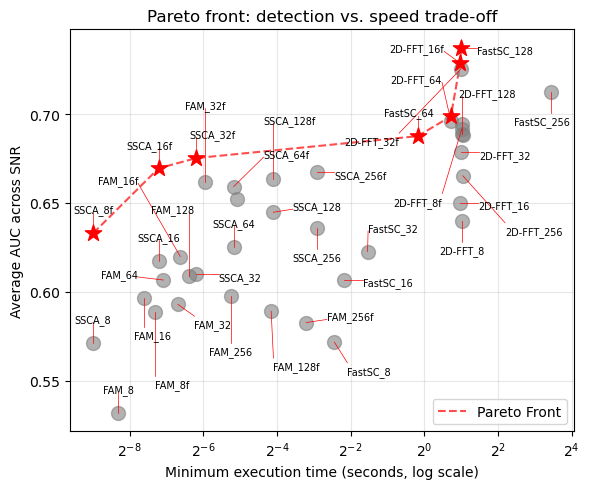

In [82]:
plot_pareto_front(times, auc, names, figsize=(6, 5), label_size=8, log_x=True, save_path='fig/pareto_front_log_new.png')

In [47]:
algorithm_conj = ['ssca', 'fam', 'ssca_flat', 'fam_flat']

auc_conj = np.zeros(len(Np) * len(algorithm_conj))
times_conj = np.zeros(len(Np) * len(algorithm_conj))

for i in range(len(algorithm_conj)):
    algo_name = algorithm[i]

    print(algo_name)
    
    for j in range(len(Np)):
        auc_conj[i * len(Np) + j] = np.mean(np.load(f"data/roc_test_{algo_name}_{Np[j]}_score_conjugate.npy"))/3

        if algo_name == 'fam_flat':
            temp_name = 'fam_flattop'
        elif algo_name == 'ssca_flat':
            temp_name = 'ssca'
        else:
            temp_name = algo_name
        
        times_conj[i * len(Np) + j] = df_time[(df_time['algorithm'] == temp_name) & (df_time['Np'] == Np[j])]['mean'].iloc[0]

print(auc_conj)
print(times)

names_conj = ['SSCA_8', 'SSCA_16', 'SSCA_32', 'SSCA_64', 'SSCA_128', 'SSCA_256',
         'FAM_8', 'FAM_16', 'FAM_32', 'FAM_64', 'FAM_128', 'FAM_256',
         'SSCA_8f', 'SSCA_16f', 'SSCA_32f', 'SSCA_64f', 'SSCA_128f', 'SSCA_256f',
         'FAM_8f', 'FAM_16f', 'FAM_32f', 'FAM_64f', 'FAM_128f', 'FAM_256f']

ssca
fam
ssca_flat
fam_flat
[0.67711111 0.71911111 0.71788889 0.70877778 0.65611111 0.59911111
 0.65477778 0.679      0.70833333 0.689      0.64955556 0.59266667
 0.67722222 0.74922222 0.75633333 0.76966667 0.71677778 0.68111111
 0.67755556 0.75366667 0.75377778 0.74855556 0.70477778 0.66688889]
[2.09323648e-03 7.21598333e-03 1.41404305e-02 2.88247940e-02
 6.05824540e-02 1.51572438e-01 3.43319938e-03 6.15822278e-03
 1.13944096e-02 1.77305080e-02 3.42101600e-02 6.70811660e-02
 2.09323648e-03 7.21598333e-03 1.41404305e-02 2.88247940e-02
 6.05824540e-02 1.51572438e-01 7.36618448e-03 1.14875378e-02
 1.66972893e-02 3.07680740e-02 5.76331000e-02 1.12319520e-01
 2.10364714e-01 2.27457004e-01 3.69428874e-01 9.25402930e-01
 2.13522269e+00 1.13360516e+01]


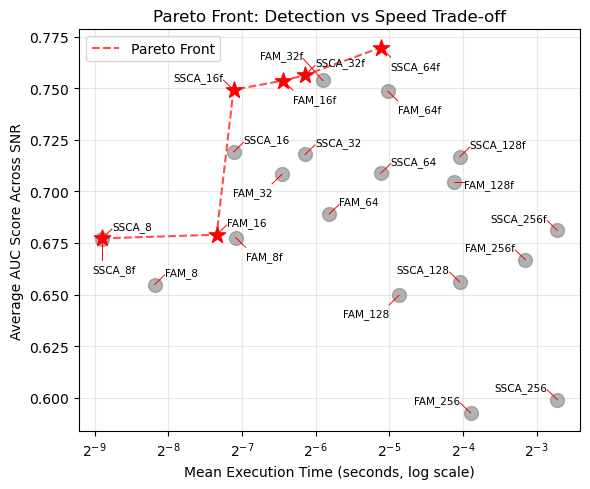

In [48]:
plot_pareto_front(times_conj, auc_conj, names_conj, figsize=(6, 5), log_x=True, save_path=None)

Starting non-conjugate ROC test...
  Rect BPSK cycle frequency: α = 0.4000
  SRRC QPSK cycle frequency: α = 0.1000
  GMSK cycle frequency:      α = 0.1000
0dB SNR Score: 2.997/3
-5dB SNR Score: 2.728/3
-10dB SNR Score: 2.156/3


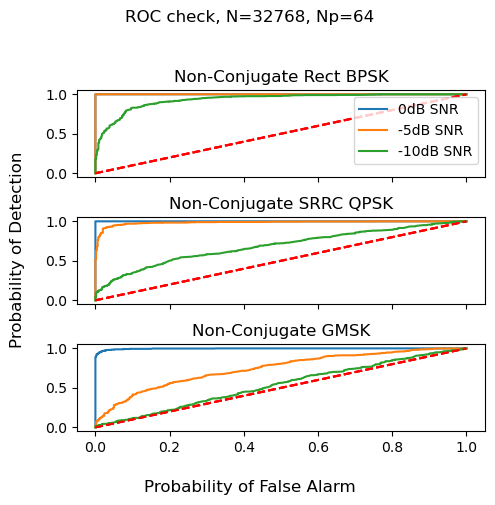

In [4]:
ssca_pd, ssca_pf, ssca_roc_auc, threshold_resolution = test.plot_roc_non_conjugate(ssca, N=2**15, Np=64, no_of_simulation=500, snr=[0, -5, -10], name="ssca_roc") 